Starting Variational EM optimization...
EM Iteration 50/200, ELBO: -93.0229
EM Iteration 100/200, ELBO: nan
EM Iteration 150/200, ELBO: nan
EM Iteration 200/200, ELBO: nan

Optimization finished.

--- Initial Z ---
[-5.         -4.4736843  -3.9473684  -3.4210525  -2.8947368  -2.368421
 -1.8421052  -1.3157893  -0.78947353 -0.26315773  0.26315773  0.78947353
  1.3157893   1.8421052   2.368421    2.8947368   3.4210525   3.9473684
  4.4736843   5.        ]

--- Optimized Z ---
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]
-------------------


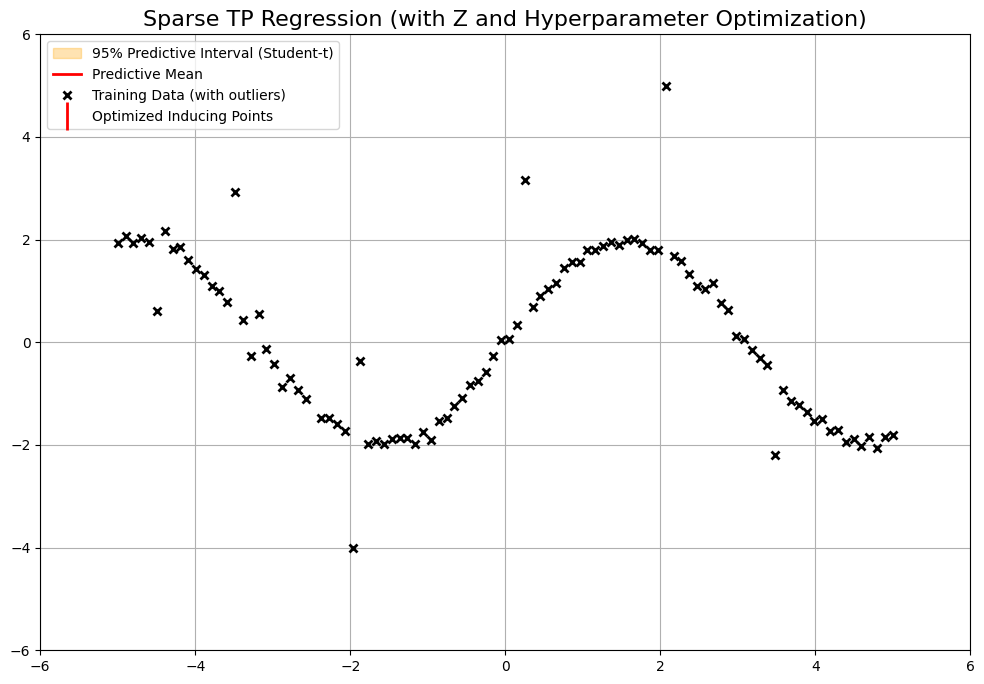

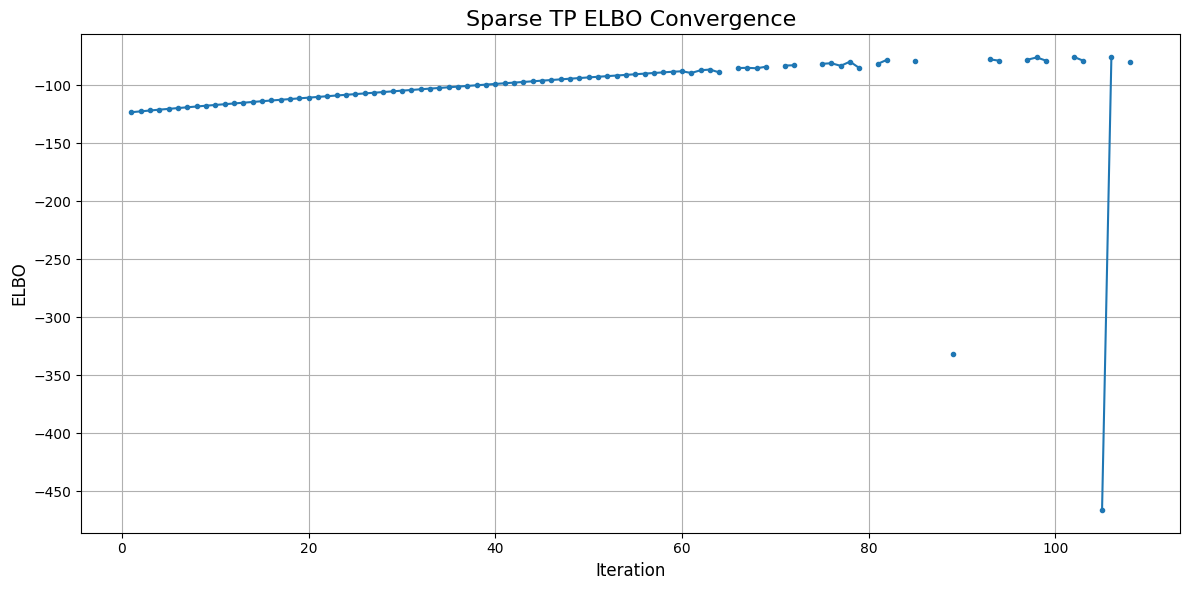

In [5]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.stats import t
import math

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    # Ensure lengthscale and variance are tensors for autograd
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

class TPRegression:
    """
    Implementation of Variational EM for Student-t Process Regression.
    - E-Step: CAVI updates for variational parameters.
    - M-Step: Gradient-based optimization of model hyperparameters and inducing points.
    """
    def __init__(self, X, y, Z_initial, nu_f=5.0, nu_e=5.0, kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0):
        self.X = X
        self.y = y.squeeze()
        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Initialize Hyperparameters and Inducing Points (M-step) ---
        # These are now learnable parameters. We optimize their log for stability.
        self.log_nu_f = torch.nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_epsilon = torch.nn.Parameter(torch.log(torch.tensor(nu_e)))
        self.log_sigma_sq = torch.nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_kernel_lengthscale = torch.nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = torch.nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.Z = torch.nn.Parameter(Z_initial.clone())

        # --- Initialize Variational Parameters (E-step) ---
        self.m_u = torch.zeros(self.M, 1)
        self.S_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N)
        self.beta_lambda = torch.ones(self.N)
        
    def _get_hyperparams(self):
        """Returns the exponentiated (positive) hyperparameters."""
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }
        
    def _e_step(self, cavi_max_iter=1):
        """Performs the CAVI updates for the variational parameters (E-Step)."""
        with torch.no_grad(): # No gradients needed for the E-step updates
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
            
            for _ in range(cavi_max_iter):
                # Update q(lambda)
                K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
                expected_f_mean = K_XZ @ K_ZZ_inv_m_u
                if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
                else: expected_r_inv = self.beta_r
                k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))
                K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
                var_f_term1 = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1))
                var_f_term2 = (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
                var_f = var_f_term1 + var_f_term2
                expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
                self.alpha_lambda = params['nu_epsilon'] / 2.0 + 0.5
                self.beta_lambda = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error

                # Update q(r)
                trace_term = torch.trace(K_ZZ_inv @ self.S_u)
                mean_term = self.m_u.T @ K_ZZ_inv @ self.m_u
                expected_u_quadratic_form = trace_term + mean_term
                self.alpha_r = params['nu_f'] / 2.0 + self.M / 2.0
                self.beta_r = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic_form.squeeze()

                # Update q(u)
                expected_r = self.alpha_r / self.beta_r
                expected_lambda = self.alpha_lambda / self.beta_lambda
                precision_u_prior = expected_r * K_ZZ_inv
                K_ZX = K_XZ.T
                A = K_ZX * (expected_lambda / params['sigma_sq'])
                B = A @ K_XZ
                precision_u_lik = K_ZZ_inv.T @ B @ K_ZZ_inv
                precision_u = precision_u_prior + precision_u_lik
                self.S_u = torch.inverse(precision_u + torch.eye(self.M) * 1e-6)
                b = K_ZZ_inv.T @ (K_ZX @ (expected_lambda * self.y / params['sigma_sq']))
                self.m_u = (self.S_u @ b).unsqueeze(1)

    def _calculate_elbo(self):
        """Calculates the Evidence Lower Bound (ELBO) for the M-step."""
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
        K_ZZ_inv = torch.inverse(K_ZZ)
        K_XZ = rbf_kernel(self.X, self.Z, params['lengthscale'], params['variance'])
        k_ii = torch.diag(rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']))

        # 1. Expected Log-Likelihood
        expected_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)
        expected_lambda = self.alpha_lambda / self.beta_lambda
        K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
        expected_f_mean = K_XZ @ K_ZZ_inv_m_u
        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        K_XZ_K_ZZ_inv = K_XZ @ K_ZZ_inv
        var_f = expected_r_inv * (k_ii - (K_XZ_K_ZZ_inv * K_XZ).sum(dim=1)) + \
                (K_XZ_K_ZZ_inv @ self.S_u * K_XZ_K_ZZ_inv).sum(dim=1)
        expected_sq_error = (self.y - expected_f_mean.squeeze()).pow(2) + var_f
        
        log_lik = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  expected_lambda / params['sigma_sq'] * expected_sq_error)

        # 2. KL Divergences
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        kl_u = 0.5 * (
            -torch.logdet(self.S_u) - self.M * expected_log_r + torch.logdet(K_ZZ) + \
            (self.alpha_r / self.beta_r) * (torch.trace(K_ZZ_inv @ self.S_u) + self.m_u.T @ K_ZZ_inv @ self.m_u) - self.M
        ).squeeze()
        
        # CORRECTED a typo here: params['nu_e'] -> params['nu_epsilon']
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda = torch.sum((self.alpha_lambda - p_alpha_lambda) * torch.digamma(self.alpha_lambda) - \
                    torch.lgamma(self.alpha_lambda) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(self.beta_lambda) - torch.log(p_beta_lambda)) + \
                    self.alpha_lambda * (p_beta_lambda - self.beta_lambda) / self.beta_lambda)

        return log_lik - kl_u - kl_r - kl_lambda

    def _m_step(self, optimizer):
        """Performs the gradient update for the hyperparameters (M-Step)."""
        optimizer.zero_grad()
        elbo = self._calculate_elbo()
        loss = -elbo # Maximize ELBO by minimizing -ELBO
        loss.backward()
        optimizer.step()
        return elbo.item()

    def fit(self, max_iter_global=100, cavi_max_iter=10, lr=0.01):
        """Runs the full Variational EM algorithm."""
        optimizer = optim.Adam(
            [self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
             self.log_kernel_lengthscale, self.log_kernel_variance, self.Z],
            lr=lr
        )
        
        elbo_history = []
        print("Starting Variational EM optimization...")
        for i in range(max_iter_global):
            self._e_step(cavi_max_iter=cavi_max_iter)
            elbo = self._m_step(optimizer)
            elbo_history.append(elbo)
            
            if (i + 1) % 50 == 0:
                print(f"EM Iteration {i+1}/{max_iter_global}, ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        """
        Makes predictions for new data X_test.
        Returns the parameters of the predictive Student-t distribution.
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M) * 1e-6
            K_ZZ_inv = torch.inverse(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = torch.diag(rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']))

            K_ZZ_inv_m_u = torch.linalg.solve(K_ZZ, self.m_u)
            pred_mean = (K_star_Z @ K_ZZ_inv_m_u).squeeze()

            K_star_Z_K_ZZ_inv = K_star_Z @ K_ZZ_inv
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u * K_star_Z_K_ZZ_inv).sum(dim=1)
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = gp_var * (self.beta_r / self.alpha_r)
            
            return pred_mean, pred_scale_sq, pred_nu

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=200, cavi_max_iter=5, lr=0.01)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, mew=2, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()
